# Episode 2: From Binary to Dense - Learning Embeddings

**Goal**: Replace sparse binary vectors with dense, learned representations

---

## What Are Embeddings?

**Embeddings** = Dense, low-dimensional vectors that capture word meaning

### Old way (BoW):
```
"movie" → [0, 0, 1, 0, 0, 0, ...] (28 dimensions, sparse)
```

### New way (Embeddings):
```
"movie" → [0.5, -0.2, 0.8, 0.3, -0.1] (5-50 dimensions, dense)
```


In [1]:
import re
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Set random seed for reproducibility
torch.manual_seed(42)

---

## Part 1: Same Dataset as Episode 1

In [2]:
docs = [
    "Movies are fun for everyone.",
    "Watching movies is great fun.",
    "Enjoy a great movie today.",
    "Research is interesting and important.",
    "Learning math is very important.",
    "Science discovery is interesting.",
    "Rock is great to listen to.",
    "Listen to music for fun.",
    "Music is fun for everyone.",
    "Listen to folk music!"
]

labels = [1, 1, 1, 3, 3, 3, 2, 2, 2, 2]  # 1=Cinema, 2=Music, 3=Science
class_names = ["Cinema", "Music", "Science"]
num_classes = len(set(labels))

print(f"Number of documents: {len(docs)}")
print(f"Number of classes: {num_classes}")

Number of documents: 10
Number of classes: 3


---

## Part 2: Build Vocabulary (Same as Before)

In [3]:
def tokenize(text):
    """Convert text to lowercase and extract words"""
    return re.findall(r"\w+", text.lower())

def get_vocabulary(texts):
    """Build vocabulary from all documents"""
    tokens = {token for text in texts for token in tokenize(text)}
    return {word: idx for idx, word in enumerate(sorted(tokens))}

vocabulary = get_vocabulary(docs)
vocab_size = len(vocabulary)

# Create reverse mapping (index -> word) for later visualization
idx_to_word = {idx: word for word, idx in vocabulary.items()}

print(f"Vocabulary size: {vocab_size}")
print("\nVocabulary:")
for word, idx in vocabulary.items():
    print(f"  {idx:2d}: '{word}'")

Vocabulary size: 26

Vocabulary:
   0: 'a'
   1: 'and'
   2: 'are'
   3: 'discovery'
   4: 'enjoy'
   5: 'everyone'
   6: 'folk'
   7: 'for'
   8: 'fun'
   9: 'great'
  10: 'important'
  11: 'interesting'
  12: 'is'
  13: 'learning'
  14: 'listen'
  15: 'math'
  16: 'movie'
  17: 'movies'
  18: 'music'
  19: 'research'
  20: 'rock'
  21: 'science'
  22: 'to'
  23: 'today'
  24: 'very'
  25: 'watching'


---

## Part 3: Convert Documents to Word Indices

**Key Change**: Instead of binary BoW vectors, we'll use **word indices** to look up embeddings.

Each document becomes a list of word indices (not a binary vector!).

In [4]:
def doc_to_indices(doc, vocabulary):
    """Convert document to list of word indices"""
    tokens = tokenize(doc)
    return [vocabulary[token] for token in tokens if token in vocabulary]

# Convert all documents to indices
doc_indices = [doc_to_indices(doc, vocabulary) for doc in docs]

# Show example
print("Example conversion:")
print(f"Document: {docs[0]}")
print(f"Tokens: {tokenize(docs[0])}")
print(f"Indices: {doc_indices[0]}")
print(f"\nDecoded back: {[idx_to_word[idx] for idx in doc_indices[0]]}")

Example conversion:
Document: Movies are fun for everyone.
Tokens: ['movies', 'are', 'fun', 'for', 'everyone']
Indices: [17, 2, 8, 7, 5]

Decoded back: ['movies', 'are', 'fun', 'for', 'everyone']


---

## Part 4: Build Embedding Classifier

### Architecture:

```
Word Indices --> Embedding Lookup --> Average Pooling --> Hidden Layer --> Output
```

### How It Works:

1. **Embedding Layer**: Lookup table `[vocab_size, embedding_dim]`
   - Each word index --> dense vector
2. Average Pooling: Average all word vectors in document
   - Variable-length input --> fixed-size vector
3. Hidden Layer + ReLU: Same as Episode 1
4. Output Layer: Classify into 3 categories

### Key Insight:

The **embedding weights are learned** during training! PyTorch automatically computes gradients for the embedding matrix.

In [5]:
embedding_dim = 10  # Dense representation (vs. vocab_size=28 for BoW)
hidden_dim = 50
output_dim = num_classes

print(f"Embedding dimension: {embedding_dim}")
print(f"Hidden dimension: {hidden_dim}")
print(f"Output dimension: {output_dim}")
print(f"\nCompare:")
print(f"  BoW representation: {vocab_size} dimensions (sparse)")
print(f"  Embedding representation: {embedding_dim} dimensions (dense)")
print(f"  Compression: {vocab_size/embedding_dim:.1f}x smaller!")

Embedding dimension: 10
Hidden dimension: 50
Output dimension: 3

Compare:
  BoW representation: 26 dimensions (sparse)
  Embedding representation: 10 dimensions (dense)
  Compression: 2.6x smaller!


In [6]:
class EmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        
        # Embedding layer: the lookup table!
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Classification layers (same as Episode 1)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        """
        x: list of word indices for a document
        Returns: logits for each class
        """
        # Look up embeddings for each word
        embeds = self.embedding(x)  # [num_words, embedding_dim]
        
        # Average pooling: collapse variable-length sequence
        pooled = embeds.mean(dim=0)  # [embedding_dim]
        
        # Classification layers
        x = self.fc1(pooled)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = EmbeddingClassifier(vocab_size, embedding_dim, hidden_dim, output_dim)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
print(f"  Embedding parameters: {vocab_size * embedding_dim}")

EmbeddingClassifier(
  (embedding): Embedding(26, 10)
  (fc1): Linear(in_features=10, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=3, bias=True)
)

Total parameters: 963
  Embedding parameters: 260


### 🔍 Let's Look Inside the Embedding Layer

The embedding layer is just a matrix! Let's see its initial (random) values.

In [7]:
print("Embedding weight matrix shape:", model.embedding.weight.shape)
print(f"  [vocab_size={vocab_size}, embedding_dim={embedding_dim}]")
print("\nInitial embedding for word 'movie' (before training):")
movie_idx = vocabulary['movie']
print(f"  Word: 'movie', Index: {movie_idx}")
print(f"  Embedding vector: {model.embedding.weight[movie_idx].detach().numpy()}")

print("\nInitial embedding for word 'music' (before training):")
music_idx = vocabulary['music']
print(f"  Word: 'music', Index: {music_idx}")
print(f"  Embedding vector: {model.embedding.weight[music_idx].detach().numpy()}")

print("\nThese are random now. After training, similar words will have similar vectors!")

Embedding weight matrix shape: torch.Size([26, 10])
  [vocab_size=26, embedding_dim=10]

Initial embedding for word 'movie' (before training):
  Word: 'movie', Index: 16
  Embedding vector: [-1.9005532   0.22857653  0.0248594  -0.34595022  0.2868321  -0.7308424
  0.17482035 -1.0939288  -1.6021603   1.3528969 ]

Initial embedding for word 'music' (before training):
  Word: 'music', Index: 18
  Embedding vector: [-0.93194777 -1.5909663  -1.1359758  -0.52259755 -0.5187733  -1.5012764
 -1.9266545   0.12785123  1.0229133  -0.5557948 ]

These are random now. After training, similar words will have similar vectors!


---

## Part 5: Training

Same training loop as Episode 1, but now the **embeddings are learning** too!

In [8]:
# Convert labels to tensor
labels_tensor = torch.tensor(labels, dtype=torch.long) - 1

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)  # Higher LR for faster convergence

print("Training configuration:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: SGD")
print(f"  Learning rate: 0.1")
print(f"  Iterations: 2000")

Training configuration:
  Loss: CrossEntropyLoss
  Optimizer: SGD
  Learning rate: 0.1
  Iterations: 2000


In [9]:
# Training loop
num_epochs = 2000
losses = []

for step in range(num_epochs):
    total_loss = 0
    
    # Process each document separately (since they have different lengths)
    for i, indices in enumerate(doc_indices):
        optimizer.zero_grad()
        
        # Convert to tensor
        x = torch.tensor(indices, dtype=torch.long)
        y = labels_tensor[i:i+1]  # Keep batch dimension
        
        # Forward pass
        output = model(x).unsqueeze(0)  # Add batch dimension
        loss = criterion(output, y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(docs)
    losses.append(avg_loss)
    
    if (step + 1) % 400 == 0:
        print(f"Epoch [{step+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Epoch [400/2000], Loss: 0.0003
Epoch [800/2000], Loss: 0.0001
Epoch [1200/2000], Loss: 0.0001
Epoch [1600/2000], Loss: 0.0001
Epoch [2000/2000], Loss: 0.0000

Training complete!


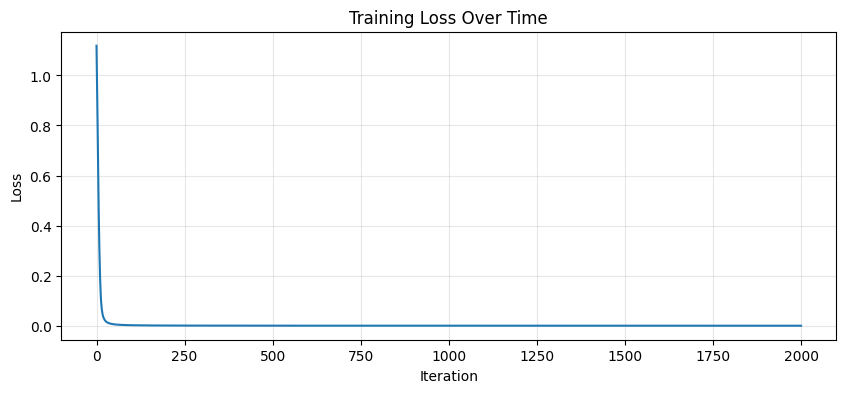

Initial loss: 1.1187
Final loss: 0.0000


In [10]:
# Visualize training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")

---

## Part 6: Evaluate Performance

In [11]:
# Evaluate on training data
model.eval()
with torch.no_grad():
    correct = 0
    print("Training Set Performance:")
    print("="*60)
    
    for i, (doc, indices) in enumerate(zip(docs, doc_indices)):
        x = torch.tensor(indices, dtype=torch.long)
        output = model(x)
        predicted = torch.argmax(output).item()
        true_label = labels_tensor[i].item()
        
        correct += (predicted == true_label)
        status = "1" if predicted == true_label else "X"
        
        print(f"{status} {doc}")
        print(f"  True: {class_names[true_label]}, Predicted: {class_names[predicted]}")
    
    accuracy = 100 * correct / len(docs)
    print(f"\nAccuracy: {accuracy:.1f}% ({correct}/{len(docs)})")

Training Set Performance:
1 Movies are fun for everyone.
  True: Cinema, Predicted: Cinema
1 Watching movies is great fun.
  True: Cinema, Predicted: Cinema
1 Enjoy a great movie today.
  True: Cinema, Predicted: Cinema
1 Research is interesting and important.
  True: Science, Predicted: Science
1 Learning math is very important.
  True: Science, Predicted: Science
1 Science discovery is interesting.
  True: Science, Predicted: Science
1 Rock is great to listen to.
  True: Music, Predicted: Music
1 Listen to music for fun.
  True: Music, Predicted: Music
1 Music is fun for everyone.
  True: Music, Predicted: Music
1 Listen to folk music!
  True: Music, Predicted: Music

Accuracy: 100.0% (10/10)


---

## Part 7: The Magic - Visualize Learned Embeddings!

Now let's look at what the model learned. **Similar words should have similar embeddings!**

In [12]:
# Extract learned embeddings
embeddings = model.embedding.weight.detach().numpy()

print("Learned Embeddings:")
print(f"Shape: {embeddings.shape} [vocab_size={vocab_size}, embedding_dim={embedding_dim}]")
print("\nEmbeddings for some key words:")

key_words = ['movie', 'movies', 'film', 'music', 'listen', 'science', 'research']
for word in key_words:
    if word in vocabulary:
        idx = vocabulary[word]
        vec = embeddings[idx]
        print(f"\n'{word}': {vec}")

Learned Embeddings:
Shape: (26, 10) [vocab_size=26, embedding_dim=10]

Embeddings for some key words:

'movie': [-1.9133974   0.26895502 -0.03099605 -0.3712341   0.3185037  -0.7201983
  0.08933004 -1.121122   -1.6262237   1.3134094 ]

'movies': [ 1.6532356   0.20158775 -1.7235491   0.5665044   1.2190515   2.2106915
 -0.45111784 -0.11729635 -1.3164959  -0.12960425]

'music': [-1.298398   -1.6152143  -1.1399003  -0.3150572  -0.84414774 -1.5888683
 -1.6590759   0.24174428  1.4480247  -0.9326354 ]

'listen': [-0.6528148   1.0247005  -0.7019357   0.79861367 -1.2135911   0.8783651
  1.7847086   1.5273786   0.6186837  -0.48728806]

'science': [-0.38589045 -0.69933367  0.20717756  0.36303717 -0.08631214 -2.3030238
 -0.30350447  1.1994343  -1.8731331   1.9049035 ]

'research': [ 0.71118003  0.67444015  1.7854406  -0.9375947   0.9710759  -0.3415808
 -1.1451335   0.38602442  0.45642802  1.434445  ]


### Compute Cosine Similarity Between Words

**Cosine similarity** measures how similar two vectors are:
- 1.0 = identical direction (very similar)
- 0.0 = orthogonal (unrelated)
- -1.0 = opposite direction (very different)

In [13]:
# Compute pairwise cosine similarities
similarities = cosine_similarity(embeddings)

def print_similar_words(word, top_k=5):
    """Find and print most similar words to given word"""
    if word not in vocabulary:
        print(f"Word '{word}' not in vocabulary")
        return
    
    word_idx = vocabulary[word]
    word_sims = similarities[word_idx]
    
    # Get top-k most similar (excluding the word itself)
    top_indices = np.argsort(word_sims)[::-1][1:top_k+1]
    
    print(f"\nMost similar words to '{word}':")
    for i, idx in enumerate(top_indices, 1):
        similar_word = idx_to_word[idx]
        similarity = word_sims[idx]
        print(f"  {i}. '{similar_word}' (similarity: {similarity:.3f})")

# Test with key words from each category
print_similar_words('movie')
print_similar_words('music')
print_similar_words('science')


Most similar words to 'movie':
  1. 'learning' (similarity: 0.533)
  2. 'science' (similarity: 0.508)
  3. 'for' (similarity: 0.500)
  4. 'math' (similarity: 0.283)
  5. 'a' (similarity: 0.274)

Most similar words to 'music':
  1. 'great' (similarity: 0.430)
  2. 'everyone' (similarity: 0.327)
  3. 'very' (similarity: 0.090)
  4. 'science' (similarity: 0.089)
  5. 'fun' (similarity: 0.081)

Most similar words to 'science':
  1. 'movie' (similarity: 0.508)
  2. 'learning' (similarity: 0.423)
  3. 'everyone' (similarity: 0.342)
  4. 'very' (similarity: 0.289)
  5. 'research' (similarity: 0.222)


### Visualize Properly trained Embeddings

In our toy example, we don't have enough data to train word embeddings AND a classifier.

Check word embeddings that have been trained with enough data:

https://projector.tensorflow.org/

* search for `movie` in the right search

![we](assets/word_embeddings.png)

---

## Part 8: Test on New Documents

In [17]:
# Test on new documents
new_docs = [
    "Listening to rock music is fun.",
    "I love science very much.",
    "Films are my passion"
]

print("Test Document Predictions:")
print("="*60)

with torch.no_grad():
    for new_doc in new_docs:
        indices = doc_to_indices(new_doc, vocabulary)
        
        if len(indices) == 0:
            print(f"\nDocument: \"{new_doc}\"")
            print("WARN: No words in vocabulary!")
            continue
        
        x = torch.tensor(indices, dtype=torch.long)
        output = model(x)
        probabilities = torch.softmax(output, dim=0)
        predicted = torch.argmax(output).item()
        
        print(f"\nDocument: \"{new_doc}\"")
        print(f"Prediction: {class_names[predicted]}")
        print(f"Confidence:")
        for j, class_name in enumerate(class_names):
            print(f"  {class_name}: {probabilities[j].item():.2%}")

Test Document Predictions:

Document: "Listening to rock music is fun."
Prediction: Music
Confidence:
  Cinema: 0.00%
  Music: 100.00%
  Science: 0.00%

Document: "I love science very much."
Prediction: Science
Confidence:
  Cinema: 0.00%
  Music: 0.00%
  Science: 100.00%

Document: "Films are my passion"
Prediction: Cinema
Confidence:
  Cinema: 76.13%
  Music: 1.06%
  Science: 22.81%


---

## Episode 2 Summary

### What We Learned:

**Embeddings are lookup tables**: Just a matrix `[vocab_size, embedding_dim]`  
**Learned through backpropagation**: Not hand-crafted, optimized for the task  
**Dense and low-dimensional**: 10-300 dims vs. 10k+ for BoW  
**Semantic relationships emerge**: Similar words → similar vectors  
**Cosine similarity measures closeness**: Visualized with heatmaps and PCA  

### Key Insights:

1. **Embeddings capture meaning**: Words used in similar contexts get similar vectors
2. **Automatic learning**: No manual feature engineering needed
3. **Dimension reduction**: 10 dims is enough for our toy problem (vs. 28 for BoW)
4. **Foundation of modern NLP**: Word2Vec, GloVe, and transformer embeddings all use this principle

### Comparison: BoW vs. Embeddings

| Feature | Bag-of-Words | Embeddings |
|---------|--------------|------------|
| Dimensionality | vocab_size (10k+) | 50-300 |
| Density | Sparse (mostly 0s) | Dense (all meaningful) |
| Semantics | No similarity | Captures similarity |
| Training | None (just counting) | Learned end-to-end |

